# Group 16 — Forest Fire Detection: Baseline + Hybrid (v2)
**Dataset:** D-Fire (14,122 train | 3,099 val | 4,306 test) | Classes: smoke, fire

## Pipeline
1. Train YOLOv8n baseline on D-Fire (20 epochs)
2. Evaluate baseline
3. **Mine false positives from val using fine-tuned baseline** (NEW)
4. Build CLIP + YOLOv8n hybrid with **enriched prompts** + **FP image anchors** (NEW)
5. Fine-tune hybrid (10 epochs, freeze + joint phases)
6. Compare baseline vs hybrid

## Two improvements in v2
**Enriched prompts** — 16 fire and 16 negative prompts spanning stage, intensity, vegetation, time of day, weather, and geographic context. Richer semantic anchor than v1's 4–5 prompts.

**FP image anchors** — confirmed false positives from the fine-tuned baseline are encoded with CLIP and mixed into TEXT_NEG at α=0.5. Anchors the contrastive loss against actual dataset-specific failures, not just generic confounder text.

$$\mathcal{L}_{total} = \mathcal{L}_{detect} + \lambda_1 \cdot \mathcal{L}_{contrastive}$$

In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
!pip install ultralytics --quiet
!pip install git+https://github.com/openai/CLIP.git --quiet

import ultralytics
ultralytics.checks()
import clip
print('CLIP ready')

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)
CLIP ready


In [2]:
# ── Cell 2: Paths and data.yaml ───────────────────────────────────────────────
import yaml
from pathlib import Path

DFIRE_ROOT = Path('/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data')

print('=== D-Fire Verification ===')
for split in ['train', 'val', 'test']:
    n = len(list((DFIRE_ROOT / split / 'images').glob('*')))
    print(f'  {split:6s}: {n:6d} images')

with open(DFIRE_ROOT.parent / 'data.yaml') as f:
    orig = yaml.safe_load(f)
CLASS_NAMES = orig['names']
print(f'\nClasses: {CLASS_NAMES}')

YAML_PATH = Path('/kaggle/working/dfire.yaml')
with open(YAML_PATH, 'w') as f:
    yaml.dump({
        'path':  str(DFIRE_ROOT),
        'train': 'train/images',
        'val':   'val/images',
        'test':  'test/images',
        'nc':    orig['nc'],
        'names': orig['names']
    }, f, default_flow_style=False)
print('data.yaml ready.')

=== D-Fire Verification ===
  train :  14122 images
  val   :   3099 images
  test  :   4306 images

Classes: ['smoke', 'fire']
data.yaml ready.


In [3]:
# ── Cell 3: Load baseline weights from saved Kaggle dataset ──────────────────
# Skips full retraining if you've already saved baseline weights.
# Comment this out and use the training cell below if no saved weights exist.

BASELINE_W = '/kaggle/input/datasets/nausherwan123/bestpt/best.pt'

from pathlib import Path
if Path(BASELINE_W).exists():
    print(f'Loading baseline weights from: {BASELINE_W}')
else:
    raise FileNotFoundError(
        f'Saved baseline weights not found at {BASELINE_W}.\n'
        f'Either train baseline (next cell) or fix the path.'
    )

Loading baseline weights from: /kaggle/input/datasets/nausherwan123/bestpt/best.pt


In [4]:
import os
for root, dirs, files in os.walk('/kaggle/input/datasets/nausherwan123/bestpt'):
    for f in files:
        full_path = os.path.join(root, f)
        size_mb = os.path.getsize(full_path) / 1e6
        print(f'{full_path}  ({size_mb:.2f} MB)')

/kaggle/input/datasets/nausherwan123/bestpt/best.pt  (6.22 MB)


In [5]:
# # ── Cell 3 ALT: Train YOLOv8n baseline (only if no saved weights) ────────────
# # Skip this cell if Cell 3 above succeeded.

# import torch
# from ultralytics import YOLO

# print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

# baseline = YOLO('yolov8n.pt')
# baseline.train(
#     data=str(YAML_PATH),
#     epochs=20,
#     imgsz=640,
#     batch=16,
#     device=0 if torch.cuda.is_available() else 'cpu',
#     workers=0,
#     seed=42,
#     patience=10,
#     cache=False,
#     save=True,
#     project='/kaggle/working/runs',
#     name='yolov8n_baseline',
#     exist_ok=True,
# )
# BASELINE_W = '/kaggle/working/runs/yolov8n_baseline/weights/best.pt'
# print(f'\nBaseline weights saved to: {BASELINE_W}')

In [6]:
# ── Cell 4: Evaluate baseline ─────────────────────────────────────────────────
import time, glob
import torch
from ultralytics import YOLO

trained_baseline = YOLO(BASELINE_W)

metrics_b = trained_baseline.val(
    data=str(YAML_PATH), split='test',
    imgsz=640, batch=16, verbose=False,
)

test_imgs = glob.glob(str(DFIRE_ROOT / 'test/images/*'))[:100]
t0 = time.time()
for p in test_imgs:
    trained_baseline.predict(p, imgsz=640, verbose=False)
fps_b = len(test_imgs) / (time.time() - t0)

p_b  = metrics_b.box.mp
r_b  = metrics_b.box.mr
f1_b = 2 * p_b * r_b / (p_b + r_b + 1e-9)

print('\n' + '='*52)
print('   YOLOv8n BASELINE — D-Fire')
print('='*52)
print(f'  mAP50        : {metrics_b.box.map50:.4f}')
print(f'  mAP50-95     : {metrics_b.box.map:.4f}')
print(f'  Precision    : {p_b:.4f}')
print(f'  Recall       : {r_b:.4f}')
print(f'  F1 Score     : {f1_b:.4f}')
print(f'  FPS (sim.)   : {fps_b:.1f}')
print('='*52)
print('\n  Per-Class AP50:')
for i, name in enumerate(CLASS_NAMES):
    try:    print(f'    {name:10s}: {metrics_b.box.ap50[i]:.4f}')
    except: print(f'    {name:10s}: N/A')

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.1 ms, read: 14.1±10.5 MB/s, size: 98.4 KB)
val: Scanning /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/labels... 4295 images, 2005 backgrounds, 15 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 105.3it/s 40.9s
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0297]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0156]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB11243.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/sayedgamal99/sm

---
## Phase 1 — False Positive Mining (NEW in v2)

Run the fine-tuned baseline on D-Fire **val** images that have empty label files (true negatives). Any detection above conf=0.25 is a confirmed false positive — a hard case where a competent fire detector still gets fooled.

**Decisions made:**
- Source: val only (test stays clean for evaluation)
- Confidence threshold: 0.25 (matches deployment threshold)
- Cap: 80 FPs (enough for stable averaging, fast to encode)

In [7]:
# ── Cell 5: Mine false positives from val using fine-tuned baseline ──────────
import random
import pandas as pd
from pathlib import Path

random.seed(42)
CONF_THRESH = 0.25
MAX_FPS     = 80

def mine_fps(model, image_dir, label_dir, conf_thresh, max_count):
    """Find images where labels are empty but model still fires above threshold."""
    fps = []
    for img_path in sorted(Path(image_dir).glob('*')):
        lbl_path = Path(label_dir) / (img_path.stem + '.txt')
        is_neg = (not lbl_path.exists()) or (lbl_path.stat().st_size == 0)
        if not is_neg:
            continue
        result = model.predict(str(img_path), conf=conf_thresh, verbose=False)[0]
        if len(result.boxes) > 0:
            fps.append({
                'path':         str(img_path),
                'n_detections': len(result.boxes),
                'max_conf':     float(result.boxes.conf.max()),
            })
            if len(fps) >= max_count:
                break
    return fps

print(f'Mining false positives from val split (conf >= {CONF_THRESH}, cap {MAX_FPS})...')
fps_val = mine_fps(
    trained_baseline,
    DFIRE_ROOT / 'val/images',
    DFIRE_ROOT / 'val/labels',
    CONF_THRESH, MAX_FPS
)

ALL_FP_PATHS = [fp['path'] for fp in fps_val]

print(f'\nFound {len(fps_val)} false positives from val.')
print('Test split untouched — no evaluation leakage.')

# Save manifest for methodology writeup
if fps_val:
    pd.DataFrame(fps_val).to_csv('/kaggle/working/mined_fps.csv', index=False)
    print('Manifest saved: /kaggle/working/mined_fps.csv')

# Sanity check — if too few FPs, lower threshold
if len(fps_val) < 30:
    print(f'\nWARNING: Only {len(fps_val)} FPs — anchor will be unstable.')
    print('Consider lowering CONF_THRESH to 0.15 and rerunning this cell.')

Mining false positives from val split (conf >= 0.25, cap 80)...

Found 35 false positives from val.
Test split untouched — no evaluation leakage.
Manifest saved: /kaggle/working/mined_fps.csv


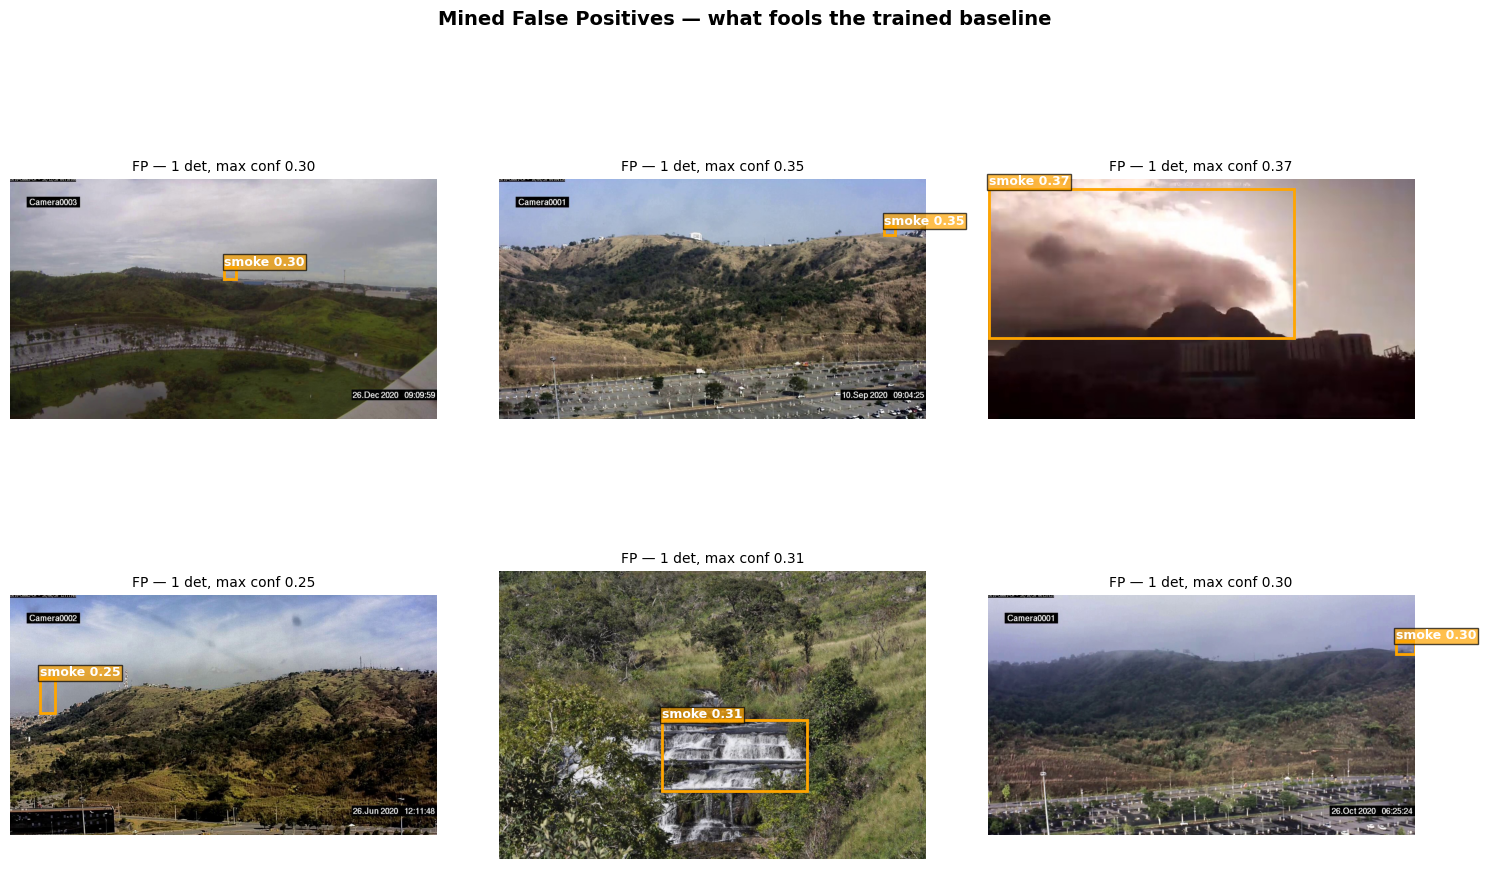


If the FPs above are skewed to one failure mode (all sunsets, all clouds, etc.)
consider lowering ALPHA_IMG in the next phase to weight text prompts more.


In [8]:
# ── Cell 6: Visualize mined false positives (sanity check) ───────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage

if len(fps_val) == 0:
    print('No FPs to visualize — skipping.')
else:
    n_show = min(6, len(fps_val))
    samples = random.sample(fps_val, n_show)
    
    cols = 3
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    axes = axes.flatten() if hasattr(axes, 'flatten') else axes
    
    for ax, fp in zip(axes, samples):
        img = PILImage.open(fp['path']).convert('RGB')
        ax.imshow(img)
        
        # Draw the model's (incorrect) detections
        result = trained_baseline.predict(
            fp['path'], conf=CONF_THRESH, verbose=False)[0]
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            cls = int(box.cls); conf = float(box.conf)
            label = CLASS_NAMES[cls]
            color = 'red' if label == 'fire' else 'orange'
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color, facecolor='none'))
            ax.text(x1, y1-5, f'{label} {conf:.2f}',
                color='white', fontsize=9, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.7, pad=1))
        
        ax.set_title(f'FP — {fp["n_detections"]} det, max conf {fp["max_conf"]:.2f}',
                     fontsize=10)
        ax.axis('off')
    
    # Hide unused axes
    for ax in axes[n_show:]:
        ax.axis('off')
    
    plt.suptitle('Mined False Positives — what fools the trained baseline',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f'\nIf the FPs above are skewed to one failure mode (all sunsets, all clouds, etc.)')
    print(f'consider lowering ALPHA_IMG in the next phase to weight text prompts more.')

---
## Phase 2 — CLIP Setup with Enriched Prompts + FP Anchors

**Enriched prompts** span 6 dimensions: smoke stage, fire intensity, vegetation, time of day, weather, smoke color. 16 prompts each for fire and negatives.

**TEXT_NEG anchor** mixes:
- 50% from averaged text negative prompts (generic semantic structure)
- 50% from averaged FP image embeddings (dataset-specific failures)

In [9]:
# ── Cell 6.5: FASDD non-forest fire paths + combine with val FPs ─────────────
# 50 manually curated FASDD images of urban/road fires.
# Justification: Margalla Hills borders Islamabad, so PTZ cameras may catch
# urban fires. We want the model to suppress these from forest fire alerts.

FASDD_BASE = '/kaggle/input/datasets/yuulind/fasdd-cv-coco/images/train'

FASDD_FP_PATHS = [
    f'{FASDD_BASE}/bothFireAndSmoke_CV000200.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000763.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000772.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000777.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000787.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000804.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000831.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000839.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000842.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000848.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000853.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000854.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000861.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000862.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000868.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000880.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000881.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000895.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000908.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000911.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000926.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000928.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000935.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000936.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000942.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV000953.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001028.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001031.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001066.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001073.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001074.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001100.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001103.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001108.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001109.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001113.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001118.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001119.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001142.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001155.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001161.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001185.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001188.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001189.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001196.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001223.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001226.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001238.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001242.jpg',
    f'{FASDD_BASE}/bothFireAndSmoke_CV001310.jpg',
]

# Sanity check — confirm all paths exist before training
import os
missing = [p for p in FASDD_FP_PATHS if not os.path.exists(p)]
if missing:
    print(f'WARNING: {len(missing)} paths do not exist:')
    for p in missing[:5]:
        print(f'  {p}')
    raise FileNotFoundError(f'{len(missing)} FASDD paths invalid — fix before training')

print(f'FASDD non-forest negatives: {len(FASDD_FP_PATHS)} images, all paths verified')

# Combine with val FPs from Cell 5
val_fp_paths = list(ALL_FP_PATHS)  # save val FPs separately
ALL_FP_PATHS = val_fp_paths + FASDD_FP_PATHS

print(f'\nTotal hard negatives: {len(ALL_FP_PATHS)}')
print(f'  Val FPs (atmospheric)  : {len(val_fp_paths)}')
print(f'  FASDD FPs (urban fires): {len(FASDD_FP_PATHS)}')

FASDD non-forest negatives: 50 images, all paths verified

Total hard negatives: 85
  Val FPs (atmospheric)  : 35
  FASDD FPs (urban fires): 50


In [10]:
# ── Cell 7: Load CLIP frozen + build enriched anchors ────────────────────────
import torch.nn.functional as F

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
for param in clip_model.parameters():
    param.requires_grad = False
clip_model.eval()

# ── Enriched FIRE prompts — 16 spanning 6 dimensions ─────────────────────────
FIRE_PROMPTS = [
    # Smoke stage
    'thin wisp of early-stage wildfire smoke rising from forest',
    'thick gray smoke plume from a developed forest fire',
    'large smoke column rising from active wildfire',
    # Fire intensity
    'small spot fire with bright orange flames in vegetation',
    'intense forest fire with tall flames consuming trees',
    'glowing embers and flames at the base of a wildfire',
    # Vegetation
    'wildfire smoke rising from burning pine forest',
    'forest fire spreading through dry scrubland',
    'grassland fire with low flames and white smoke',
    # Time of day
    'wildfire smoke against bright daytime blue sky',
    'forest fire glow visible at dusk in dark woodland',
    'orange wildfire flames at night against dark forest',
    # Weather
    'wildfire smoke rising on a clear sunny day',
    'forest fire smoke through overcast cloudy sky',
    # Smoke color
    'dark black smoke from burning oily vegetation',
    'white smoke from smoldering forest debris',
]

# ── Enriched NEGATIVE prompts — 16 covering known failure modes ──────────────
NEG_PROMPTS = [
    # Cloud variations
    'white cumulus cloud floating over a green mountain',
    'gray stratus clouds covering a forested ridge',
    'isolated puffy cloud against blue sky over trees',
    # Mist and fog
    'morning mist rolling through a forest valley at sunrise',
    'thick fog blanketing trees on a humid morning',
    'low-lying mist hugging the ground in cool air',
    # Time-of-day glare
    'bright orange sunset glare on the horizon',
    'sunrise light casting orange hues across a mountain',
    'sun rays breaking through clouds at golden hour',
    # Atmospheric phenomena
    'heat haze shimmering above hot ground in summer',
    'dust cloud kicked up by wind over dry terrain',
    'lens flare from direct sunlight in the camera',
    # Wet conditions
    'steam rising from wet forest ground after rainfall',
    'water vapor evaporating from wet leaves in sunlight',
    # Geographic specific (relevant for Margalla foothills)
    'cloud formation hugging a mountain ridge from below',
    'aerial view of forest with patchy cloud cover',
]

# ── Encode text prompts ──────────────────────────────────────────────────────
with torch.no_grad():
    text_fire_embed = F.normalize(
        clip_model.encode_text(clip.tokenize(FIRE_PROMPTS).to(DEVICE)), dim=-1
    ).mean(dim=0, keepdim=True).float()
    
    text_neg_embed = F.normalize(
        clip_model.encode_text(clip.tokenize(NEG_PROMPTS).to(DEVICE)), dim=-1
    ).mean(dim=0, keepdim=True).float()

TEXT_FIRE = text_fire_embed

# ── Encode mined FP images and mix into TEXT_NEG ─────────────────────────────
ALPHA_IMG = 0.5  # 50% image-derived, 50% text-derived

if ALL_FP_PATHS:
    print(f'Encoding {len(ALL_FP_PATHS)} mined false positives with CLIP...')
    fp_embeds = []
    with torch.no_grad():
        for path in ALL_FP_PATHS:
            img = PILImage.open(path).convert('RGB')
            img_tensor = clip_preprocess(img).unsqueeze(0).to(DEVICE)
            embed = clip_model.encode_image(img_tensor)
            embed = F.normalize(embed.float(), dim=-1)
            fp_embeds.append(embed)
    
    fp_embeds_tensor = torch.cat(fp_embeds, dim=0)
    image_neg_embed  = fp_embeds_tensor.mean(dim=0, keepdim=True)
    
    # Mix and renormalize
    TEXT_NEG = F.normalize(
        ALPHA_IMG * image_neg_embed + (1 - ALPHA_IMG) * text_neg_embed,
        dim=-1
    )
    print(f'TEXT_NEG anchor mixed: {ALPHA_IMG*100:.0f}% image / {(1-ALPHA_IMG)*100:.0f}% text')
else:
    TEXT_NEG = text_neg_embed
    print('No mined FPs — using text-only negatives.')

print(f'\nCLIP frozen. Anchors ready:')
print(f'  TEXT_FIRE shape: {TEXT_FIRE.shape}')
print(f'  TEXT_NEG  shape: {TEXT_NEG.shape}')
print(f'  Fire prompts : {len(FIRE_PROMPTS)}')
print(f'  Neg  prompts : {len(NEG_PROMPTS)}')
print(f'  FP images    : {len(ALL_FP_PATHS)}')

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 128MiB/s]


Encoding 85 mined false positives with CLIP...
TEXT_NEG anchor mixed: 50% image / 50% text

CLIP frozen. Anchors ready:
  TEXT_FIRE shape: torch.Size([1, 512])
  TEXT_NEG  shape: torch.Size([1, 512])
  Fire prompts : 16
  Neg  prompts : 16
  FP images    : 85


---
## Phase 3 — CLIP+YOLO Hybrid Architecture

- CLIP image features fused into YOLO P5 features (identity init)
- Fused P5 routed back into Detection Head
- Contrastive head projects fused features → 512d for comparison with TEXT_FIRE / TEXT_NEG

In [11]:
# ── Cell 8: CLIPYOLOv8 model definition (identity init, fused P5 to head) ───
import torch
import torch.nn as nn
import torch.nn.functional as F

YOLO_NECK_CH = 256


class FusionHead(nn.Module):
    """Concatenate CLIP context with YOLO P5, fused with 1x1 conv.
    Identity initialization — at epoch 0, output ≈ original P5."""
    def __init__(self, yolo_ch=256, clip_dim=512):
        super().__init__()
        self.clip_proj = nn.Linear(clip_dim, yolo_ch)
        self.fuse_conv = nn.Conv2d(yolo_ch * 2, yolo_ch, kernel_size=1, bias=False)
        self.bn        = nn.BatchNorm2d(yolo_ch)
        self.act       = nn.SiLU()

        # Identity init: YOLO half = identity, CLIP half = zeros
        with torch.no_grad():
            self.fuse_conv.weight.zero_()
            for c in range(yolo_ch):
                self.fuse_conv.weight[c, c, 0, 0] = 1.0
            self.bn.weight.fill_(1.0)
            self.bn.bias.zero_()

    def forward(self, yolo_feat, clip_vec):
        B, C, H, W = yolo_feat.shape
        clip_proj    = self.clip_proj(clip_vec)
        clip_spatial = clip_proj.view(B, C, 1, 1).expand(B, C, H, W)
        fused        = torch.cat([yolo_feat, clip_spatial], dim=1)
        return self.act(self.bn(self.fuse_conv(fused)))


class ContrastiveHead(nn.Module):
    """Projects fused YOLO features into CLIP's 512d text space."""
    def __init__(self, yolo_ch=256, clip_dim=512):
        super().__init__()
        self.proj = nn.Linear(yolo_ch, clip_dim)

    def forward(self, fused_feat):
        pooled = fused_feat.mean(dim=[2, 3])
        embed  = self.proj(pooled)
        return F.normalize(embed, dim=-1)


class CLIPYOLOWrapper(nn.Module):
    def __init__(self, yolo_weights, clip_model, yolo_ch=256, clip_dim=512):
        super().__init__()
        yolo        = YOLO(yolo_weights)
        self.yolo   = yolo.model
        self.clip   = clip_model
        self.fusion = FusionHead(yolo_ch, clip_dim)
        self.contra = ContrastiveHead(yolo_ch, clip_dim)

        self._features = {}
        self._hooks = []
        for layer_idx in [15, 18, 21]:
            h = self.yolo.model[layer_idx].register_forward_hook(
                self._make_hook(layer_idx)
            )
            self._hooks.append(h)

    def _make_hook(self, layer_idx):
        def hook(module, input, output):
            self._features[layer_idx] = output
        return hook

    def forward(self, images, clip_images):
        self._features.clear()
        x = images
        saved = {}
        for i, m in enumerate(self.yolo.model[:22]):
            if m.f != -1:
                if isinstance(m.f, int):
                    x = saved[m.f]
                else:
                    x = [x if j == -1 else saved[j] for j in m.f]
            x = m(x)
            saved[i] = x

        p3 = self._features[15]
        p4 = self._features[18]
        p5 = self._features[21]

        with torch.no_grad():
            clip_vec = self.clip.encode_image(clip_images)
            clip_vec = F.normalize(clip_vec.float(), dim=-1)

        p5_fused   = self.fusion(p5, clip_vec)
        yolo_embed = self.contra(p5_fused)

        detect_module = self.yolo.model[22]
        preds = detect_module([p3, p4, p5_fused])
        return preds, yolo_embed

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()


hybrid_model = CLIPYOLOWrapper(BASELINE_W, clip_model).to(DEVICE)

trainable_params = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
frozen_params    = sum(p.numel() for p in clip_model.parameters())
print(f'Trainable: {trainable_params:,}')
print(f'Frozen   : {frozen_params:,}')
print('Fusion initialized as identity — epoch 0 output ≈ original P5')

Trainable: 394,496
Frozen   : 151,277,313
Fusion initialized as identity — epoch 0 output ≈ original P5


In [12]:
# ── Cell 9: Contrastive loss + dataset ───────────────────────────────────────
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T


def contrastive_loss(yolo_embed, has_fire, text_fire, text_neg, temperature=1.0):
    """Pulls fire images toward TEXT_FIRE, pulls negatives toward TEXT_NEG.
    Temperature=1.0 prevents saturation in early epochs."""
    text_fire = text_fire.to(yolo_embed.dtype)
    text_neg  = text_neg.to(yolo_embed.dtype)

    fire_sim = (yolo_embed @ text_fire.T).squeeze(-1)
    neg_sim  = (yolo_embed @ text_neg.T).squeeze(-1)
    pos_mask = has_fire.bool()
    neg_mask = ~pos_mask
    loss = torch.tensor(0.0, device=yolo_embed.device, dtype=yolo_embed.dtype)
    if pos_mask.sum() > 0:
        loss = loss - fire_sim[pos_mask].mean()
    if neg_mask.sum() > 0:
        loss = loss - neg_sim[neg_mask].mean()
    return loss / temperature


class DFireDataset(Dataset):
    def __init__(self, img_dir, label_dir, clip_preprocess, img_size=640):
        self.img_paths  = sorted(Path(img_dir).glob('*'))
        self.label_dir  = Path(label_dir)
        self.clip_pre   = clip_preprocess
        self.yolo_trans = T.Compose([T.Resize((img_size, img_size)), T.ToTensor()])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        lbl_path = self.label_dir / (img_path.stem + '.txt')
        img      = PILImage.open(img_path).convert('RGB')
        has_fire = 1 if (lbl_path.exists() and lbl_path.stat().st_size > 0) else 0
        return (
            self.yolo_trans(img),
            self.clip_pre(img),
            str(lbl_path),
            has_fire
        )


train_ds = DFireDataset(
    DFIRE_ROOT / 'train/images',
    DFIRE_ROOT / 'train/labels',
    clip_preprocess
)
train_loader = DataLoader(
    train_ds, batch_size=8, shuffle=True,
    num_workers=0, pin_memory=False,
)

fire_count = sum(
    1 for p in train_ds.img_paths
    if (train_ds.label_dir / (p.stem + '.txt')).exists() and
       (train_ds.label_dir / (p.stem + '.txt')).stat().st_size > 0
)
print(f'Training samples : {len(train_ds):,}')
print(f'Batches per epoch: {len(train_loader):,}')
print(f'Fire/smoke images: {fire_count:,} | Background: {len(train_ds)-fire_count:,}')

Training samples : 14,122
Batches per epoch: 1,766
Fire/smoke images: 7,664 | Background: 6,458


In [13]:
# ── Cell 10: Hybrid training loop with checkpointed validation ───────────────
import gc
import time
import json
import pandas as pd
from pathlib import Path
from types import SimpleNamespace

import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from ultralytics import YOLO
from ultralytics.utils.loss import v8DetectionLoss

torch.cuda.empty_cache()
gc.collect()
print(f'GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')

# ── Fixed run settings ───────────────────────────────────────────────────────
LAMBDA_1      = 0.5
NUM_EPOCHS    = 20
FREEZE_EPOCHS = 3
LR            = 5e-4

# Only show/save final validation metrics from epoch 10 onward, every 2 epochs
EVAL_MILESTONES = list(range(10, 21, 2))

# Where checkpoints/results will be saved
RUN_DIR = Path('/kaggle/working/hybrid_epoch_sweep_lambda_0_5_alpha_0_5')
CKPT_DIR = RUN_DIR / 'checkpoints'
RUN_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f'\nRun directory: {RUN_DIR}')
print(f'Checkpoints directory: {CKPT_DIR}')

# ── Detection loss setup ─────────────────────────────────────────────────────
detect_loss_fn = v8DetectionLoss(hybrid_model.yolo)

if isinstance(detect_loss_fn.hyp, dict):
    detect_loss_fn.hyp = SimpleNamespace(**detect_loss_fn.hyp)

for attr, default in [('box', 7.5), ('cls', 0.5), ('dfl', 1.5)]:
    if not hasattr(detect_loss_fn.hyp, attr):
        setattr(detect_loss_fn.hyp, attr, default)

print(f'\nLoss: L_detect + {LAMBDA_1} * L_contrastive')
print(f'Epochs: {NUM_EPOCHS} | Freeze: {FREEZE_EPOCHS} | LR: {LR} | Batch: 8 | Alpha: {ALPHA_IMG}')
print(f'Validation checkpoints: {EVAL_MILESTONES}')

hybrid_model.train()
history = []
checkpoint_results = []

# ── Helper: evaluate only YOLO part from hybrid model ────────────────────────
def evaluate_yolo_from_hybrid(hybrid_model, split='val'):
    """
    Evaluates only the YOLO weights from the hybrid model.
    CLIP, fusion, and contrastive heads are not used during evaluation.
    """
    hybrid_model.eval()

    eval_yolo = YOLO(BASELINE_W)

    yolo_state = {
        k.replace('yolo.', ''): v
        for k, v in hybrid_model.state_dict().items()
        if k.startswith('yolo.')
    }

    eval_yolo.model.load_state_dict(yolo_state, strict=False)

    metrics = eval_yolo.val(
        data=str(YAML_PATH),
        split=split,
        imgsz=640,
        batch=16,
        verbose=False,
    )

    p = float(metrics.box.mp)
    r = float(metrics.box.mr)
    f1 = 2 * p * r / (p + r + 1e-9)

    hybrid_model.train()

    return metrics, p, r, f1


# ── Helper: save hybrid checkpoint and extracted YOLO checkpoint ─────────────
def save_checkpoint_at_epoch(hybrid_model, epoch, metrics, p, r, f1):
    """
    Saves:
    1. Full hybrid state_dict
    2. YOLO-only state_dict extracted from hybrid
    3. A JSON metadata file for that checkpoint
    """
    epoch_tag = f'epoch_{epoch:02d}'

    hybrid_path = CKPT_DIR / f'hybrid_{epoch_tag}.pt'
    yolo_path   = CKPT_DIR / f'yolo_only_{epoch_tag}.pt'
    meta_path   = CKPT_DIR / f'metrics_{epoch_tag}.json'

    # Save full hybrid model
    torch.save(hybrid_model.state_dict(), hybrid_path)

    # Save YOLO-only extracted weights
    yolo_state = {
        k.replace('yolo.', ''): v
        for k, v in hybrid_model.state_dict().items()
        if k.startswith('yolo.')
    }
    torch.save(yolo_state, yolo_path)

    # Metrics row
    row = {
        'epoch': epoch,
        'lambda': float(LAMBDA_1),
        'alpha': float(ALPHA_IMG),
        'mAP50': round(float(metrics.box.map50), 6),
        'mAP50_95': round(float(metrics.box.map), 6),
        'precision': round(float(p), 6),
        'recall': round(float(r), 6),
        'f1': round(float(f1), 6),
        'AP50_smoke': round(float(metrics.box.ap50[0]), 6) if len(metrics.box.ap50) > 0 else None,
        'AP50_fire': round(float(metrics.box.ap50[1]), 6) if len(metrics.box.ap50) > 1 else None,
        'hybrid_checkpoint': str(hybrid_path),
        'yolo_only_checkpoint': str(yolo_path),
    }

    with open(meta_path, 'w') as f:
        json.dump(row, f, indent=2)

    return row


# ── Phase A: freeze YOLO first ───────────────────────────────────────────────
print(f'\n[Phase A] Freezing YOLO for first {FREEZE_EPOCHS} epochs')

for name, param in hybrid_model.named_parameters():
    if name.startswith('yolo.'):
        param.requires_grad = False

optimizer = AdamW(
    [p for p in hybrid_model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_map50 = -1.0
best_epoch = None
best_hybrid_path = RUN_DIR / 'best_hybrid_by_val_map50.pt'
best_yolo_path   = RUN_DIR / 'best_yolo_only_by_val_map50.pt'


# ── Main training loop ───────────────────────────────────────────────────────
for epoch in range(NUM_EPOCHS):

    # Unfreeze YOLO after FREEZE_EPOCHS
    if epoch == FREEZE_EPOCHS:
        print(f'\n[Phase B] Unfreezing YOLO — full joint training')

        for name, param in hybrid_model.named_parameters():
            if name.startswith('yolo.'):
                param.requires_grad = True

        optimizer = AdamW(
            [p for p in hybrid_model.parameters() if p.requires_grad],
            lr=LR,
            weight_decay=1e-4
        )

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=NUM_EPOCHS - FREEZE_EPOCHS
        )

    e_det = e_con = e_tot = n_bat = 0

    for yolo_imgs, clip_imgs, lbl_paths, has_fire in train_loader:
        yolo_imgs = yolo_imgs.to(DEVICE)
        clip_imgs = clip_imgs.to(DEVICE)
        has_fire  = has_fire.float().to(DEVICE)

        preds, yolo_embed = hybrid_model(yolo_imgs, clip_imgs)

        # ── Detection labels ────────────────────────────────────────────────
        batch_labels = []

        for i, lp in enumerate(lbl_paths):
            if Path(lp).exists() and Path(lp).stat().st_size > 0:
                boxes = torch.from_numpy(np.loadtxt(lp, ndmin=2)).float().to(DEVICE)

                if boxes.ndim == 1:
                    boxes = boxes.unsqueeze(0)

                bi = torch.full((boxes.shape[0], 1), i, device=DEVICE)
                batch_labels.append(torch.cat([bi, boxes], dim=1))

        batch_labels = (
            torch.cat(batch_labels, dim=0)
            if batch_labels
            else torch.zeros((0, 6), device=DEVICE)
        )

        batch_dict = {
            'batch_idx': batch_labels[:, 0].long(),
            'cls':       batch_labels[:, 1:2],
            'bboxes':    batch_labels[:, 2:6],
        }

        # ── Losses ──────────────────────────────────────────────────────────
        L_detect, _ = detect_loss_fn(preds, batch_dict)

        if L_detect.numel() > 1:
            L_detect = L_detect.sum()

        L_contrast = contrastive_loss(yolo_embed, has_fire, TEXT_FIRE, TEXT_NEG)
        L_total    = L_detect + LAMBDA_1 * L_contrast

        optimizer.zero_grad()
        L_total.backward()
        torch.nn.utils.clip_grad_norm_(hybrid_model.parameters(), max_norm=10.0)
        optimizer.step()

        e_det += float(L_detect.item())
        e_con += float(L_contrast.item())
        e_tot += float(L_total.item())
        n_bat += 1

    scheduler.step()

    # Training loss row
    row = {
        'epoch':      epoch + 1,
        'phase':      'frozen' if epoch < FREEZE_EPOCHS else 'joint',
        'L_detect':   round(e_det / n_bat, 4),
        'L_contrast': round(e_con / n_bat, 4),
        'L_total':    round(e_tot / n_bat, 4),
    }

    history.append(row)

    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} [{row["phase"]}] | '
          f'L_detect={row["L_detect"]:.4f} | '
          f'L_contrast={row["L_contrast"]:.4f} | '
          f'L_total={row["L_total"]:.4f}')

    # Save training history every epoch
    pd.DataFrame(history).to_csv(RUN_DIR / 'training_loss_history.csv', index=False)

    # Validation + checkpoint from epoch 10 onward every 2 epochs
    if (epoch + 1) in EVAL_MILESTONES:
        print('\n' + '='*70)
        print(f'Validation checkpoint at epoch {epoch+1}')
        print('='*70)

        metrics_val, p_val, r_val, f1_val = evaluate_yolo_from_hybrid(
            hybrid_model,
            split='val'
        )

        ckpt_row = save_checkpoint_at_epoch(
            hybrid_model=hybrid_model,
            epoch=epoch + 1,
            metrics=metrics_val,
            p=p_val,
            r=r_val,
            f1=f1_val
        )

        checkpoint_results.append(ckpt_row)

        # Save all checkpoint results after every validation checkpoint
        df_ckpts = pd.DataFrame(checkpoint_results)
        df_ckpts.to_csv(RUN_DIR / 'checkpoint_validation_results.csv', index=False)

        print(f'Epoch {epoch+1} validation results:')
        print(f'  mAP50      : {ckpt_row["mAP50"]:.4f}')
        print(f'  mAP50-95   : {ckpt_row["mAP50_95"]:.4f}')
        print(f'  Precision  : {ckpt_row["precision"]:.4f}')
        print(f'  Recall     : {ckpt_row["recall"]:.4f}')
        print(f'  F1         : {ckpt_row["f1"]:.4f}')
        print(f'  AP50 Smoke : {ckpt_row["AP50_smoke"]}')
        print(f'  AP50 Fire  : {ckpt_row["AP50_fire"]}')
        print(f'  Saved hybrid checkpoint   : {ckpt_row["hybrid_checkpoint"]}')
        print(f'  Saved YOLO-only checkpoint: {ckpt_row["yolo_only_checkpoint"]}')

        # Save best checkpoint by validation mAP50
        if ckpt_row['mAP50'] > best_map50:
            best_map50 = ckpt_row['mAP50']
            best_epoch = epoch + 1

            torch.save(hybrid_model.state_dict(), best_hybrid_path)

            yolo_state = {
                k.replace('yolo.', ''): v
                for k, v in hybrid_model.state_dict().items()
                if k.startswith('yolo.')
            }
            torch.save(yolo_state, best_yolo_path)

            print(f'\nNew best model saved by val mAP50!')
            print(f'  Best epoch: {best_epoch}')
            print(f'  Best val mAP50: {best_map50:.4f}')
            print(f'  Best hybrid path: {best_hybrid_path}')
            print(f'  Best YOLO-only path: {best_yolo_path}')

        print('='*70 + '\n')

# Final save after epoch 20
final_hybrid_path = RUN_DIR / 'hybrid_final_epoch_20.pt'
torch.save(hybrid_model.state_dict(), final_hybrid_path)

print('\nTraining complete.')
print(f'Final hybrid checkpoint saved: {final_hybrid_path}')
print(f'Best validation epoch: {best_epoch}')
print(f'Best validation mAP50: {best_map50:.4f}')
print(f'All results saved in: {RUN_DIR}')

df_hist = pd.DataFrame(history)
df_ckpts = pd.DataFrame(checkpoint_results)

print('\nTraining loss history:')
display(df_hist)

print('\nValidation checkpoint results:')
display(df_ckpts)

GPU memory allocated: 0.42 GB

Run directory: /kaggle/working/hybrid_epoch_sweep_lambda_0_5_alpha_0_5
Checkpoints directory: /kaggle/working/hybrid_epoch_sweep_lambda_0_5_alpha_0_5/checkpoints

Loss: L_detect + 0.5 * L_contrastive
Epochs: 20 | Freeze: 3 | LR: 0.0005 | Batch: 8 | Alpha: 0.5
Validation checkpoints: [10, 12, 14, 16, 18, 20]

[Phase A] Freezing YOLO for first 3 epochs
Epoch  1/20 [frozen] | L_detect=40.1624 | L_contrast=-1.8047 | L_total=39.2601
Epoch  2/20 [frozen] | L_detect=39.3319 | L_contrast=-1.8438 | L_total=38.4100
Epoch  3/20 [frozen] | L_detect=39.1367 | L_contrast=-1.8489 | L_total=38.2123

[Phase B] Unfreezing YOLO — full joint training
Epoch  4/20 [joint] | L_detect=40.1641 | L_contrast=-1.8494 | L_total=39.2394
Epoch  5/20 [joint] | L_detect=38.0103 | L_contrast=-1.8509 | L_total=37.0848
Epoch  6/20 [joint] | L_detect=36.1253 | L_contrast=-1.8545 | L_total=35.1980
Epoch  7/20 [joint] | L_detect=34.4876 | L_contrast=-1.8496 | L_total=33.5628
Epoch  8/20 [joint

,epoch,phase,L_detect,L_contrast,L_total
0,1,frozen,40.1624,-1.8047,39.2601
1,2,frozen,39.3319,-1.8438,38.4100
2,3,frozen,39.1367,-1.8489,38.2123
3,4,joint,40.1641,-1.8494,39.2394
4,5,joint,38.0103,-1.8509,37.0848
5,6,joint,36.1253,-1.8545,35.1980
6,7,joint,34.4876,-1.8496,33.5628
7,8,joint,32.9729,-1.8540,32.0459
8,9,joint,31.5958,-1.8519,30.6699
9,10,joint,29.6278,-1.8531,28.7012



Validation checkpoint results:


,epoch,lambda,alpha,mAP50,mAP50_95,precision,recall,f1,AP50_smoke,AP50_fire,hybrid_checkpoint,yolo_only_checkpoint
0,10,0.5,0.5,0.504101,0.229798,0.549951,0.504002,0.525975,0.465287,0.542916,/kaggle/working/hybrid_epoch_sweep_lambda_0_5_...,/kaggle/working/hybrid_epoch_sweep_lambda_0_5_...
1,12,0.5,0.5,0.508615,0.235084,0.543445,0.490446,0.515587,0.450779,0.566451,/kaggle/working/hybrid_epoch_sweep_lambda_0_5_...,/kaggle/working/hybrid_epoch_sweep_lambda_0_5_...
2,14,0.5,0.5,0.465650,0.213152,0.526761,0.453852,0.487596,0.377046,0.554254,/kaggle/working/hybrid_epoch_sweep_lambda_0_5_...,/kaggle/working/hybrid_epoch_sweep_lambda_0_5_...
3,16,0.5,0.5,0.451004,0.204622,0.513090,0.447832,0.478245,0.355101,0.546906,/kaggle/working/hybrid_epoch_sweep_lambda_0_5_...,/kaggle/working/hybrid_epoch_sweep_lambda_0_5_...
4,18,0.5,0.5,0.427082,0.191443,0.510666,0.423719,0.463147,0.308347,0.545818,/kaggle/working/hybrid_epoch_sweep_lambda_0_5_...,/kaggle/working/hybrid_epoch_sweep_lambda_0_5_...
5,20,0.5,0.5,0.430656,0.192322,0.513954,0.433269,0.470175,0.318426,0.542886,/kaggle/working/hybrid_epoch_sweep_lambda_0_5_...,/kaggle/working/hybrid_epoch_sweep_lambda_0_5_...


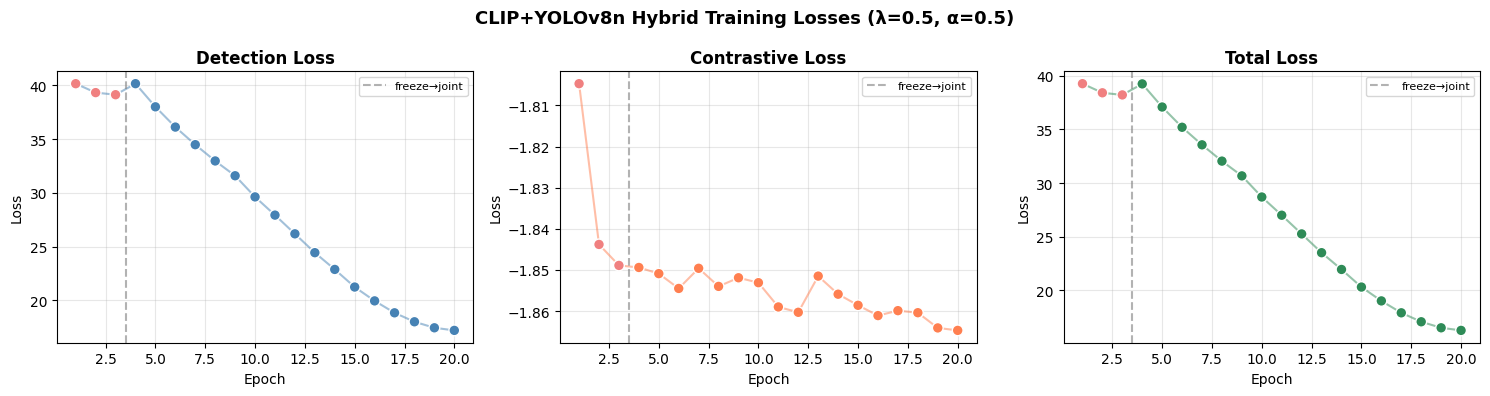


Loss history:
 epoch  phase  L_detect  L_contrast  L_total
     1 frozen   40.1624     -1.8047  39.2601
     2 frozen   39.3319     -1.8438  38.4100
     3 frozen   39.1367     -1.8489  38.2123
     4  joint   40.1641     -1.8494  39.2394
     5  joint   38.0103     -1.8509  37.0848
     6  joint   36.1253     -1.8545  35.1980
     7  joint   34.4876     -1.8496  33.5628
     8  joint   32.9729     -1.8540  32.0459
     9  joint   31.5958     -1.8519  30.6699
    10  joint   29.6278     -1.8531  28.7012
    11  joint   27.9337     -1.8590  27.0042
    12  joint   26.1924     -1.8603  25.2623
    13  joint   24.4385     -1.8515  23.5128
    14  joint   22.8800     -1.8559  21.9520
    15  joint   21.2412     -1.8586  20.3119
    16  joint   19.9532     -1.8611  19.0227
    17  joint   18.8436     -1.8599  17.9137
    18  joint   18.0090     -1.8604  17.0788
    19  joint   17.4497     -1.8641  16.5176
    20  joint   17.2081     -1.8647  16.2758


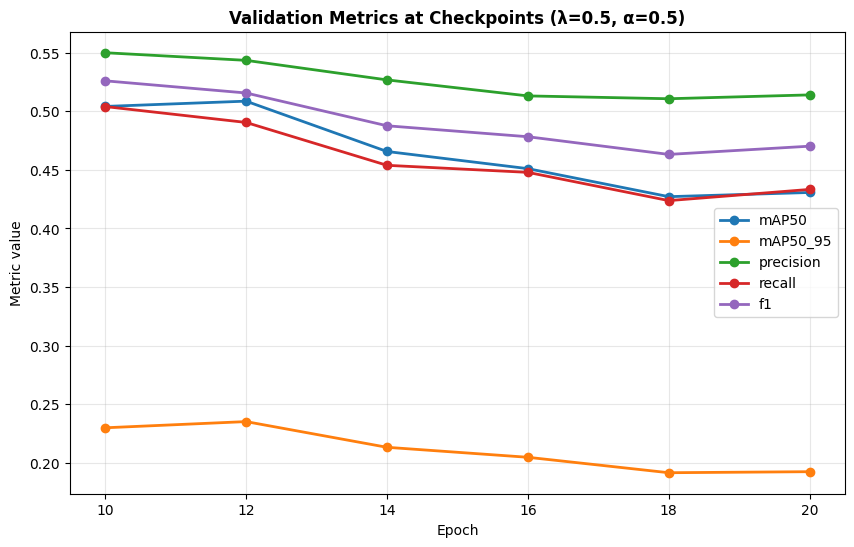


Validation checkpoint results:
 epoch  lambda  alpha    mAP50  mAP50_95  precision   recall       f1  AP50_smoke  AP50_fire                                                                      hybrid_checkpoint                                                                      yolo_only_checkpoint
    10     0.5    0.5 0.504101  0.229798   0.549951 0.504002 0.525975    0.465287   0.542916 /kaggle/working/hybrid_epoch_sweep_lambda_0_5_alpha_0_5/checkpoints/hybrid_epoch_10.pt /kaggle/working/hybrid_epoch_sweep_lambda_0_5_alpha_0_5/checkpoints/yolo_only_epoch_10.pt
    12     0.5    0.5 0.508615  0.235084   0.543445 0.490446 0.515587    0.450779   0.566451 /kaggle/working/hybrid_epoch_sweep_lambda_0_5_alpha_0_5/checkpoints/hybrid_epoch_12.pt /kaggle/working/hybrid_epoch_sweep_lambda_0_5_alpha_0_5/checkpoints/yolo_only_epoch_12.pt
    14     0.5    0.5 0.465650  0.213152   0.526761 0.453852 0.487596    0.377046   0.554254 /kaggle/working/hybrid_epoch_sweep_lambda_0_5_alpha_0_5/checkpoin

In [14]:
# ── Cell 11: Training loss curves + checkpoint metric curves ─────────────────
import matplotlib.pyplot as plt
import pandas as pd

df_hist = pd.DataFrame(history)
df_ckpts = pd.DataFrame(checkpoint_results)

# Save again just to be safe
df_hist.to_csv(RUN_DIR / 'training_loss_history.csv', index=False)
df_ckpts.to_csv(RUN_DIR / 'checkpoint_validation_results.csv', index=False)

# ── Training loss curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color, title in zip(
    axes,
    ['L_detect', 'L_contrast', 'L_total'],
    ['steelblue', 'coral', 'seagreen'],
    ['Detection Loss', 'Contrastive Loss', 'Total Loss']
):
    colors = ['lightcoral' if p == 'frozen' else color for p in df_hist['phase']]

    ax.plot(df_hist['epoch'], df_hist[col], color=color, linewidth=1.5, alpha=0.5)
    ax.scatter(
        df_hist['epoch'],
        df_hist[col],
        c=colors,
        s=60,
        zorder=3,
        edgecolors='white'
    )

    ax.axvline(
        FREEZE_EPOCHS + 0.5,
        linestyle='--',
        color='gray',
        alpha=0.6,
        label='freeze→joint'
    )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle(
    f'CLIP+YOLOv8n Hybrid Training Losses (λ={LAMBDA_1}, α={ALPHA_IMG})',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print('\nLoss history:')
print(df_hist.to_string(index=False))


# ── Validation metric curves at checkpoints ──────────────────────────────────
if len(df_ckpts) > 0:
    metric_cols = ['mAP50', 'mAP50_95', 'precision', 'recall', 'f1']

    plt.figure(figsize=(10, 6))

    for col in metric_cols:
        plt.plot(
            df_ckpts['epoch'],
            df_ckpts[col],
            marker='o',
            linewidth=2,
            label=col
        )

    plt.title(
        f'Validation Metrics at Checkpoints (λ={LAMBDA_1}, α={ALPHA_IMG})',
        fontweight='bold'
    )
    plt.xlabel('Epoch')
    plt.ylabel('Metric value')
    plt.xticks(df_ckpts['epoch'].tolist())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print('\nValidation checkpoint results:')
    print(df_ckpts.to_string(index=False))

    print(f'\nSaved files:')
    print(f'  Loss history CSV: {RUN_DIR / "training_loss_history.csv"}')
    print(f'  Validation results CSV: {RUN_DIR / "checkpoint_validation_results.csv"}')
else:
    print('No checkpoint validation results found.')

In [15]:
# ── Cell 12: Evaluate best validation checkpoint on D-Fire test ──────────────
import time
import pandas as pd
from ultralytics import YOLO

print(f'Loading best checkpoint from epoch {best_epoch}...')
print(f'Best hybrid checkpoint: {best_hybrid_path}')

# Load best full hybrid checkpoint
hybrid_model.load_state_dict(torch.load(best_hybrid_path, map_location=DEVICE))
hybrid_model.eval()

# Extract YOLO-only model for inference/evaluation
eval_yolo = YOLO(BASELINE_W)

yolo_state = {
    k.replace('yolo.', ''): v
    for k, v in hybrid_model.state_dict().items()
    if k.startswith('yolo.')
}

eval_yolo.model.load_state_dict(yolo_state, strict=False)

# Test metrics
metrics_h = eval_yolo.val(
    data=str(YAML_PATH),
    split='test',
    imgsz=640,
    batch=16,
    verbose=False,
)

# FPS estimate on test images
t0 = time.time()

for p in test_imgs:
    eval_yolo.predict(p, imgsz=640, verbose=False)

fps_h = len(test_imgs) / (time.time() - t0)

p_h  = float(metrics_h.box.mp)
r_h  = float(metrics_h.box.mr)
f1_h = 2 * p_h * r_h / (p_h + r_h + 1e-9)

test_results = {
    'chosen_epoch': best_epoch,
    'lambda': float(LAMBDA_1),
    'alpha': float(ALPHA_IMG),
    'mAP50': round(float(metrics_h.box.map50), 6),
    'mAP50_95': round(float(metrics_h.box.map), 6),
    'precision': round(float(p_h), 6),
    'recall': round(float(r_h), 6),
    'f1': round(float(f1_h), 6),
    'fps': round(float(fps_h), 3),
    'AP50_smoke': round(float(metrics_h.box.ap50[0]), 6) if len(metrics_h.box.ap50) > 0 else None,
    'AP50_fire': round(float(metrics_h.box.ap50[1]), 6) if len(metrics_h.box.ap50) > 1 else None,
    'best_hybrid_checkpoint': str(best_hybrid_path),
    'best_yolo_only_checkpoint': str(best_yolo_path),
}

df_test = pd.DataFrame([test_results])
df_test.to_csv(RUN_DIR / 'best_checkpoint_test_results.csv', index=False)

print('\n' + '='*65)
print(f'   BEST CLIP+YOLOv8n HYBRID — D-Fire Test')
print(f'   λ={LAMBDA_1}, α={ALPHA_IMG}, chosen epoch={best_epoch}')
print('='*65)
print(f'  mAP50        : {metrics_h.box.map50:.4f}')
print(f'  mAP50-95     : {metrics_h.box.map:.4f}')
print(f'  Precision    : {p_h:.4f}')
print(f'  Recall       : {r_h:.4f}')
print(f'  F1 Score     : {f1_h:.4f}')
print(f'  FPS (sim.)   : {fps_h:.1f}')
print('='*65)

print('\n  Per-Class AP50:')

for i, name in enumerate(CLASS_NAMES):
    try:
        print(f'    {name:10s}: {metrics_h.box.ap50[i]:.4f}')
    except:
        print(f'    {name:10s}: N/A')

print('\nSaved final test results:')
print(RUN_DIR / 'best_checkpoint_test_results.csv')

Loading best checkpoint from epoch 12...
Best hybrid checkpoint: /kaggle/working/hybrid_epoch_sweep_lambda_0_5_alpha_0_5/best_hybrid_by_val_map50.pt
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 169.4±106.8 MB/s, size: 110.2 KB)
val: Scanning /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/labels... 4295 images, 2005 backgrounds, 15 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 613.5it/s 7.0s
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0297]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0156]
val: /kaggle/input/datasets/sayedgamal99/smoke-fir


        BASELINE vs BEST-CHECKPOINT HYBRID — FINAL COMPARISON

Final comparison table:


,Model,Epoch,Lambda,Alpha,mAP50,mAP50-95,Precision,Recall,F1,FPS
0,YOLOv8n Baseline,baseline,-,-,0.7057,0.3912,0.7112,0.6365,0.6718,59.1285
1,CLIP+YOLOv8n Hybrid,12,0.5,0.5,0.4914,0.2194,0.5338,0.4821,0.5066,81.7615
2,Δ Hybrid - Baseline,,,,-0.2143,-0.1718,-0.1774,-0.1544,-0.1651,22.6330



Saved comparison CSV:
/kaggle/working/hybrid_epoch_sweep_lambda_0_5_alpha_0_5/baseline_vs_best_hybrid_comparison.csv

---------------------------------------------------------------------------
Summary
---------------------------------------------------------------------------
Baseline mAP50        : 0.7057
Hybrid mAP50          : 0.4914
Change in mAP50       : -0.2143

Baseline mAP50-95     : 0.3912
Hybrid mAP50-95       : 0.2194
Change in mAP50-95    : -0.1718

Baseline Precision    : 0.7112
Hybrid Precision      : 0.5338
Change in Precision   : -0.1774

Baseline Recall       : 0.6365
Hybrid Recall         : 0.4821
Change in Recall      : -0.1544

Baseline F1           : 0.6718
Hybrid F1             : 0.5066
Change in F1          : -0.1651

Baseline FPS          : 59.13
Hybrid FPS            : 81.76
Change in FPS         : +22.63
---------------------------------------------------------------------------

Best hybrid checkpoint chosen from validation epoch: 12
Lambda: 0.5
Alpha: 0.5

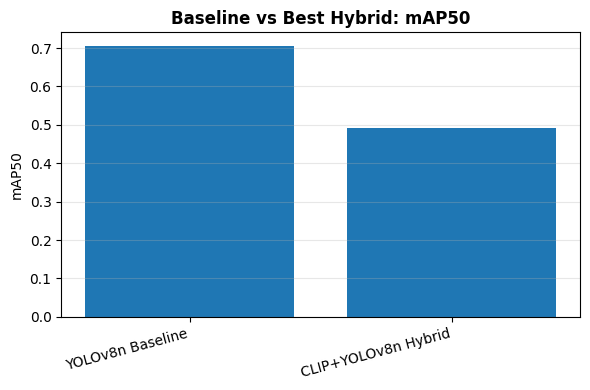

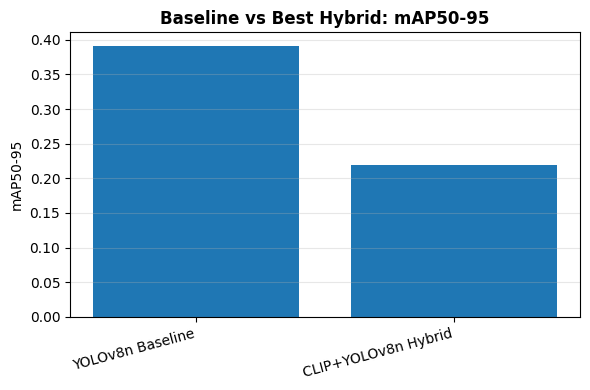

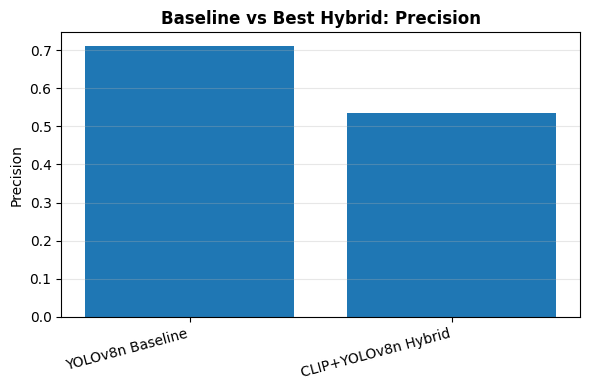

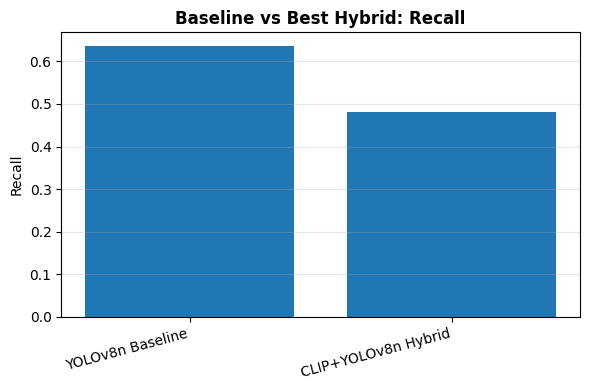

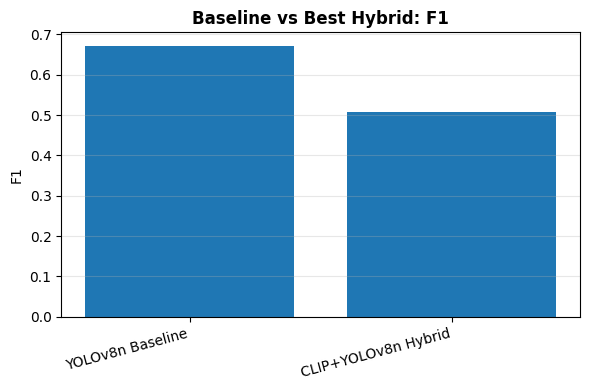

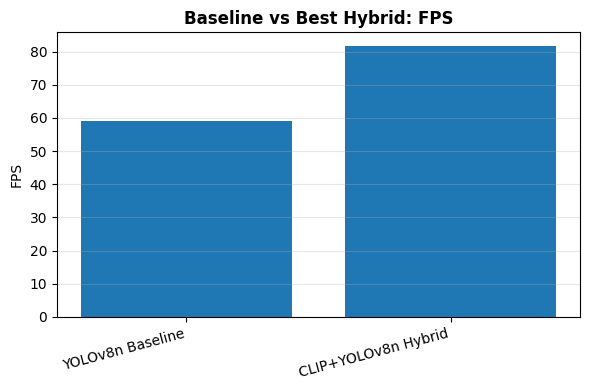

In [16]:
# ── Cell 13: Baseline vs Best-Checkpoint Hybrid Final Comparison ─────────────
import pandas as pd
import matplotlib.pyplot as plt

print('\n' + '='*75)
print('        BASELINE vs BEST-CHECKPOINT HYBRID — FINAL COMPARISON')
print('='*75)

# Safety checks
required_vars = [
    'metrics_b', 'p_b', 'r_b', 'f1_b', 'fps_b',
    'metrics_h', 'p_h', 'r_h', 'f1_h', 'fps_h',
    'LAMBDA_1', 'ALPHA_IMG', 'best_epoch'
]

missing = [v for v in required_vars if v not in globals()]

if missing:
    raise NameError(
        f"Missing variables: {missing}\n"
        "Make sure you ran the baseline evaluation cell, then Cell 10, Cell 12, and then this Cell 13."
    )

# Build comparison table
rows = [
    {
        'Model': 'YOLOv8n Baseline',
        'Epoch': 'baseline',
        'Lambda': '-',
        'Alpha': '-',
        'mAP50': float(metrics_b.box.map50),
        'mAP50-95': float(metrics_b.box.map),
        'Precision': float(p_b),
        'Recall': float(r_b),
        'F1': float(f1_b),
        'FPS': float(fps_b),
    },
    {
        'Model': f'CLIP+YOLOv8n Hybrid',
        'Epoch': int(best_epoch),
        'Lambda': float(LAMBDA_1),
        'Alpha': float(ALPHA_IMG),
        'mAP50': float(metrics_h.box.map50),
        'mAP50-95': float(metrics_h.box.map),
        'Precision': float(p_h),
        'Recall': float(r_h),
        'F1': float(f1_h),
        'FPS': float(fps_h),
    }
]

df_comparison = pd.DataFrame(rows)

# Add delta row: Hybrid - Baseline
delta_row = {
    'Model': 'Δ Hybrid - Baseline',
    'Epoch': '',
    'Lambda': '',
    'Alpha': '',
    'mAP50': df_comparison.loc[1, 'mAP50'] - df_comparison.loc[0, 'mAP50'],
    'mAP50-95': df_comparison.loc[1, 'mAP50-95'] - df_comparison.loc[0, 'mAP50-95'],
    'Precision': df_comparison.loc[1, 'Precision'] - df_comparison.loc[0, 'Precision'],
    'Recall': df_comparison.loc[1, 'Recall'] - df_comparison.loc[0, 'Recall'],
    'F1': df_comparison.loc[1, 'F1'] - df_comparison.loc[0, 'F1'],
    'FPS': df_comparison.loc[1, 'FPS'] - df_comparison.loc[0, 'FPS'],
}

df_comparison = pd.concat(
    [df_comparison, pd.DataFrame([delta_row])],
    ignore_index=True
)

# Rounded display version
df_display = df_comparison.copy()

for col in ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1', 'FPS']:
    df_display[col] = df_display[col].astype(float).round(4)

print('\nFinal comparison table:')
display(df_display)

# Save comparison results
comparison_path = RUN_DIR / 'baseline_vs_best_hybrid_comparison.csv'
df_display.to_csv(comparison_path, index=False)

print(f'\nSaved comparison CSV:')
print(comparison_path)

# Pretty console summary
baseline = df_comparison.iloc[0]
hybrid = df_comparison.iloc[1]
delta = df_comparison.iloc[2]

print('\n' + '-'*75)
print('Summary')
print('-'*75)
print(f'Baseline mAP50        : {baseline["mAP50"]:.4f}')
print(f'Hybrid mAP50          : {hybrid["mAP50"]:.4f}')
print(f'Change in mAP50       : {delta["mAP50"]:+.4f}')
print()
print(f'Baseline mAP50-95     : {baseline["mAP50-95"]:.4f}')
print(f'Hybrid mAP50-95       : {hybrid["mAP50-95"]:.4f}')
print(f'Change in mAP50-95    : {delta["mAP50-95"]:+.4f}')
print()
print(f'Baseline Precision    : {baseline["Precision"]:.4f}')
print(f'Hybrid Precision      : {hybrid["Precision"]:.4f}')
print(f'Change in Precision   : {delta["Precision"]:+.4f}')
print()
print(f'Baseline Recall       : {baseline["Recall"]:.4f}')
print(f'Hybrid Recall         : {hybrid["Recall"]:.4f}')
print(f'Change in Recall      : {delta["Recall"]:+.4f}')
print()
print(f'Baseline F1           : {baseline["F1"]:.4f}')
print(f'Hybrid F1             : {hybrid["F1"]:.4f}')
print(f'Change in F1          : {delta["F1"]:+.4f}')
print()
print(f'Baseline FPS          : {baseline["FPS"]:.2f}')
print(f'Hybrid FPS            : {hybrid["FPS"]:.2f}')
print(f'Change in FPS         : {delta["FPS"]:+.2f}')
print('-'*75)

print(f'\nBest hybrid checkpoint chosen from validation epoch: {best_epoch}')
print(f'Lambda: {LAMBDA_1}')
print(f'Alpha: {ALPHA_IMG}')

# Bar chart comparison
metrics_to_plot = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1', 'FPS']

plot_df = df_comparison.iloc[:2].copy()

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    plt.bar(plot_df['Model'], plot_df[metric])
    plt.title(f'Baseline vs Best Hybrid: {metric}', fontweight='bold')
    plt.ylabel(metric)
    plt.xticks(rotation=15, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [17]:
# # ── Cell 14: Lambda Ablation ─────────────────────────────────────────────────
# # Runs the same hybrid training pipeline at multiple lambda values
# # and produces a comparison table including the existing λ=0.5 result.
# #
# # Each run: freeze 3 epochs + joint 7 epochs (matches main run)
# # All other settings (α=0.5, enriched prompts, FP anchors) stay fixed
# # so the only variable is lambda.

# import copy
# import gc
# import pandas as pd
# import torch
# from torch.optim import AdamW
# from torch.optim.lr_scheduler import CosineAnnealingLR
# from ultralytics.utils.loss import v8DetectionLoss
# from types import SimpleNamespace

# # Lambda values to test (we already have 0.5)
# LAMBDA_SWEEP = [0.1, 0.3, 1.0]

# # Store existing λ=0.5 result first
# ablation_rows = [{
#     'Lambda':     0.5,
#     'mAP50':      round(float(metrics_h.box.map50), 4),
#     'mAP50-95':   round(float(metrics_h.box.map),   4),
#     'Precision':  round(p_h, 4),
#     'Recall':     round(r_h, 4),
#     'F1':         round(f1_h, 4),
#     'AP50_Smoke': round(float(metrics_h.box.ap50[0]), 4) if hasattr(metrics_h.box, 'ap50') else None,
#     'AP50_Fire':  round(float(metrics_h.box.ap50[1]), 4) if hasattr(metrics_h.box, 'ap50') else None,
#     'note':       'main run',
# }]

# # Sweep
# for lam in LAMBDA_SWEEP:
#     print('\n' + '='*60)
#     print(f'  Lambda = {lam} | freeze=3 + joint=7 epochs')
#     print('='*60)

#     # Free memory
#     torch.cuda.empty_cache()
#     gc.collect()

#     # Fresh model from baseline weights
#     abl_model = CLIPYOLOWrapper(BASELINE_W, clip_model).to(DEVICE)
#     abl_model.train()

#     # Freeze YOLO backbone (Phase A)
#     for name, param in abl_model.named_parameters():
#         if name.startswith('yolo.'):
#             param.requires_grad = False

#     abl_opt = AdamW(
#         [p for p in abl_model.parameters() if p.requires_grad],
#         lr=LR, weight_decay=1e-4
#     )

#     # Loss function setup
#     abl_loss_fn = v8DetectionLoss(abl_model.yolo)
#     if isinstance(abl_loss_fn.hyp, dict):
#         abl_loss_fn.hyp = SimpleNamespace(**abl_loss_fn.hyp)
#     for attr, default in [('box', 7.5), ('cls', 0.5), ('dfl', 1.5)]:
#         if not hasattr(abl_loss_fn.hyp, attr):
#             setattr(abl_loss_fn.hyp, attr, default)

#     # Training loop
#     for epoch in range(NUM_EPOCHS):
#         # Unfreeze at FREEZE_EPOCHS (Phase B)
#         if epoch == FREEZE_EPOCHS:
#             for name, param in abl_model.named_parameters():
#                 if name.startswith('yolo.'):
#                     param.requires_grad = True
#             abl_opt = AdamW(
#                 [p for p in abl_model.parameters() if p.requires_grad],
#                 lr=LR, weight_decay=1e-4
#             )

#         e_det = e_con = n_bat = 0
#         for yolo_imgs, clip_imgs, lbl_paths, has_fire in train_loader:
#             yolo_imgs = yolo_imgs.to(DEVICE)
#             clip_imgs = clip_imgs.to(DEVICE)
#             has_fire  = has_fire.float().to(DEVICE)

#             preds, yolo_embed = abl_model(yolo_imgs, clip_imgs)

#             # Detection loss
#             batch_labels = []
#             for i, lp in enumerate(lbl_paths):
#                 if Path(lp).exists() and Path(lp).stat().st_size > 0:
#                     boxes = torch.from_numpy(np.loadtxt(lp, ndmin=2)).float().to(DEVICE)
#                     if boxes.ndim == 1:
#                         boxes = boxes.unsqueeze(0)
#                     bi = torch.full((boxes.shape[0], 1), i, device=DEVICE)
#                     batch_labels.append(torch.cat([bi, boxes], dim=1))
#             batch_labels = torch.cat(batch_labels, dim=0) if batch_labels \
#                            else torch.zeros((0, 6), device=DEVICE)
#             batch_dict = {
#                 'batch_idx': batch_labels[:, 0].long(),
#                 'cls':       batch_labels[:, 1:2],
#                 'bboxes':    batch_labels[:, 2:6],
#             }
#             L_detect, _ = abl_loss_fn(preds, batch_dict)
#             if L_detect.numel() > 1:
#                 L_detect = L_detect.sum()

#             # Contrastive loss with current lambda
#             L_contrast = contrastive_loss(yolo_embed, has_fire, TEXT_FIRE, TEXT_NEG)
#             L_total = L_detect + lam * L_contrast

#             abl_opt.zero_grad()
#             L_total.backward()
#             torch.nn.utils.clip_grad_norm_(abl_model.parameters(), max_norm=10.0)
#             abl_opt.step()

#             e_det += L_detect.item()
#             e_con += L_contrast.item()
#             n_bat += 1

#         phase = 'frozen' if epoch < FREEZE_EPOCHS else 'joint'
#         print(f'  Epoch {epoch+1:2d}/{NUM_EPOCHS} [{phase}] | '
#               f'L_det={e_det/n_bat:.3f} | L_con={e_con/n_bat:.3f}')

#     # Evaluate this lambda's hybrid
#     abl_model.eval()
#     eval_yolo_abl = YOLO(BASELINE_W)
#     yolo_state_abl = {k.replace('yolo.', ''): v
#                       for k, v in abl_model.state_dict().items()
#                       if k.startswith('yolo.')}
#     eval_yolo_abl.model.load_state_dict(yolo_state_abl, strict=False)

#     m = eval_yolo_abl.val(
#         data=str(YAML_PATH), split='test',
#         imgsz=640, batch=16, verbose=False,
#     )

#     prec_a = m.box.mp
#     rec_a  = m.box.mr
#     f1_a   = 2 * prec_a * rec_a / (prec_a + rec_a + 1e-9)

#     row = {
#         'Lambda':     lam,
#         'mAP50':      round(float(m.box.map50), 4),
#         'mAP50-95':   round(float(m.box.map),   4),
#         'Precision':  round(prec_a, 4),
#         'Recall':     round(rec_a,  4),
#         'F1':         round(f1_a,   4),
#         'AP50_Smoke': round(float(m.box.ap50[0]), 4) if hasattr(m.box, 'ap50') else None,
#         'AP50_Fire':  round(float(m.box.ap50[1]), 4) if hasattr(m.box, 'ap50') else None,
#         'note':       'sweep',
#     }
#     ablation_rows.append(row)

#     print(f'\n  → mAP50={row["mAP50"]} | P={row["Precision"]} | '
#           f'R={row["Recall"]} | F1={row["F1"]}')

# # ── Save weights for this lambda ──────────────────────────────────────────
#     weight_path = f'/kaggle/working/hybrid_lambda_{lam:.2f}.pt'
#     torch.save(abl_model.state_dict(), weight_path)
#     print(f'  Weights saved: {weight_path}')

#     # Free memory before next iteration
#     del abl_model, abl_opt, abl_loss_fn, eval_yolo_abl
#     torch.cuda.empty_cache()
#     gc.collect()


# # ── Final ablation table ─────────────────────────────────────────────────────
# df_abl = pd.DataFrame(ablation_rows).sort_values('Lambda').reset_index(drop=True)

# print('\n' + '='*85)
# print('                          LAMBDA ABLATION RESULTS')
# print('='*85)
# print(df_abl.to_string(index=False))
# print('='*85)

# # Add baseline row for reference
# print(f'\n  Baseline reference: mAP50={metrics_b.box.map50:.4f} | '
#       f'P={p_b:.4f} | R={r_b:.4f} | F1={f1_b:.4f}')

# # Highlight best by F1
# best_idx = df_abl['F1'].idxmax()
# best = df_abl.iloc[best_idx]
# print(f'\n  Best by F1: λ={best["Lambda"]} '
#       f'(mAP50={best["mAP50"]}, F1={best["F1"]})')

# # Save
# df_abl.to_csv('/kaggle/working/lambda_ablation.csv', index=False)
# print('\nSaved: /kaggle/working/lambda_ablation.csv')

In [18]:
# # ── Cell 15: Alpha Ablation (λ=0.5 fixed, sweep α in TEXT_NEG mixing) ────────
# # Fixes the winning λ=0.5 from lambda ablation and sweeps α — the weight
# # that controls image-vs-text contribution to the negative anchor.
# #
# # α=0.0  → text prompts only (no image FP influence)
# # α=0.5  → balanced (your existing main run)
# # α=1.0  → mined images only (no text prompts)
# #
# # Each run: freeze 3 + joint 7 epochs, λ=0.5 throughout
# # All other settings stay identical to main run

# import copy
# import gc
# import pandas as pd
# import torch
# from torch.optim import AdamW
# from ultralytics.utils.loss import v8DetectionLoss
# from types import SimpleNamespace

# # Alpha values to test (skip 0.5 — already have it)
# ALPHA_SWEEP = [0.0, 0.3, 0.7, 1.0]
# LAMBDA_FIXED = 0.5

# # Store existing α=0.5 result first (from your main run)
# alpha_rows = [{
#     'Alpha':      0.5,
#     'mAP50':      round(float(metrics_h.box.map50), 4),
#     'mAP50-95':   round(float(metrics_h.box.map),   4),
#     'Precision':  round(p_h, 4),
#     'Recall':     round(r_h, 4),
#     'F1':         round(f1_h, 4),
#     'AP50_Smoke': round(float(metrics_h.box.ap50[0]), 4) if hasattr(metrics_h.box, 'ap50') else None,
#     'AP50_Fire':  round(float(metrics_h.box.ap50[1]), 4) if hasattr(metrics_h.box, 'ap50') else None,
#     'note':       'main run',
# }]

# # Sweep
# for alpha in ALPHA_SWEEP:
#     print('\n' + '='*60)
#     print(f'  Alpha = {alpha} | Lambda = {LAMBDA_FIXED} fixed')
#     print('='*60)

#     torch.cuda.empty_cache()
#     gc.collect()

#     # ── Rebuild TEXT_NEG with new alpha ──────────────────────────────────────
#     # Encode FPs again (already done but redoing for clarity)
#     if alpha == 0.0:
#         TEXT_NEG_alpha = text_neg_embed   # text prompts only
#     elif alpha == 1.0:
#         # image embeddings only — recompute from cached fp_embeds_tensor
#         TEXT_NEG_alpha = F.normalize(fp_embeds_tensor.mean(dim=0, keepdim=True), dim=-1)
#     else:
#         TEXT_NEG_alpha = F.normalize(
#             alpha * image_neg_embed + (1 - alpha) * text_neg_embed,
#             dim=-1
#         )

#     # Sanity check anchor separation
#     sim = (TEXT_FIRE @ TEXT_NEG_alpha.T).item()
#     print(f'  Anchor separation: TEXT_FIRE vs TEXT_NEG cosine = {sim:.4f}')

#     # ── Fresh model from baseline weights ────────────────────────────────────
#     abl_model = CLIPYOLOWrapper(BASELINE_W, clip_model).to(DEVICE)
#     abl_model.train()

#     # Freeze YOLO (Phase A)
#     for name, param in abl_model.named_parameters():
#         if name.startswith('yolo.'):
#             param.requires_grad = False

#     abl_opt = AdamW(
#         [p for p in abl_model.parameters() if p.requires_grad],
#         lr=LR, weight_decay=1e-4
#     )

#     abl_loss_fn = v8DetectionLoss(abl_model.yolo)
#     if isinstance(abl_loss_fn.hyp, dict):
#         abl_loss_fn.hyp = SimpleNamespace(**abl_loss_fn.hyp)
#     for attr, default in [('box', 7.5), ('cls', 0.5), ('dfl', 1.5)]:
#         if not hasattr(abl_loss_fn.hyp, attr):
#             setattr(abl_loss_fn.hyp, attr, default)

#     # ── Training loop ────────────────────────────────────────────────────────
#     for epoch in range(NUM_EPOCHS):
#         if epoch == FREEZE_EPOCHS:
#             for name, param in abl_model.named_parameters():
#                 if name.startswith('yolo.'):
#                     param.requires_grad = True
#             abl_opt = AdamW(
#                 [p for p in abl_model.parameters() if p.requires_grad],
#                 lr=LR, weight_decay=1e-4
#             )

#         e_det = e_con = n_bat = 0
#         for yolo_imgs, clip_imgs, lbl_paths, has_fire in train_loader:
#             yolo_imgs = yolo_imgs.to(DEVICE)
#             clip_imgs = clip_imgs.to(DEVICE)
#             has_fire  = has_fire.float().to(DEVICE)

#             preds, yolo_embed = abl_model(yolo_imgs, clip_imgs)

#             batch_labels = []
#             for i, lp in enumerate(lbl_paths):
#                 if Path(lp).exists() and Path(lp).stat().st_size > 0:
#                     boxes = torch.from_numpy(np.loadtxt(lp, ndmin=2)).float().to(DEVICE)
#                     if boxes.ndim == 1:
#                         boxes = boxes.unsqueeze(0)
#                     bi = torch.full((boxes.shape[0], 1), i, device=DEVICE)
#                     batch_labels.append(torch.cat([bi, boxes], dim=1))
#             batch_labels = torch.cat(batch_labels, dim=0) if batch_labels \
#                            else torch.zeros((0, 6), device=DEVICE)
#             batch_dict = {
#                 'batch_idx': batch_labels[:, 0].long(),
#                 'cls':       batch_labels[:, 1:2],
#                 'bboxes':    batch_labels[:, 2:6],
#             }
#             L_detect, _ = abl_loss_fn(preds, batch_dict)
#             if L_detect.numel() > 1:
#                 L_detect = L_detect.sum()

#             # Contrastive uses the alpha-specific TEXT_NEG
#             L_contrast = contrastive_loss(yolo_embed, has_fire, TEXT_FIRE, TEXT_NEG_alpha)
#             L_total = L_detect + LAMBDA_FIXED * L_contrast

#             abl_opt.zero_grad()
#             L_total.backward()
#             torch.nn.utils.clip_grad_norm_(abl_model.parameters(), max_norm=10.0)
#             abl_opt.step()

#             e_det += L_detect.item()
#             e_con += L_contrast.item()
#             n_bat += 1

#         phase = 'frozen' if epoch < FREEZE_EPOCHS else 'joint'
#         print(f'  Epoch {epoch+1:2d}/{NUM_EPOCHS} [{phase}] | '
#               f'L_det={e_det/n_bat:.3f} | L_con={e_con/n_bat:.3f}')

#     # ── Evaluate ─────────────────────────────────────────────────────────────
#     abl_model.eval()
#     eval_yolo_abl = YOLO(BASELINE_W)
#     yolo_state_abl = {k.replace('yolo.', ''): v
#                       for k, v in abl_model.state_dict().items()
#                       if k.startswith('yolo.')}
#     eval_yolo_abl.model.load_state_dict(yolo_state_abl, strict=False)

#     m = eval_yolo_abl.val(
#         data=str(YAML_PATH), split='test',
#         imgsz=640, batch=16, verbose=False,
#     )

#     prec_a = m.box.mp
#     rec_a  = m.box.mr
#     f1_a   = 2 * prec_a * rec_a / (prec_a + rec_a + 1e-9)

#     row = {
#         'Alpha':      alpha,
#         'mAP50':      round(float(m.box.map50), 4),
#         'mAP50-95':   round(float(m.box.map),   4),
#         'Precision':  round(prec_a, 4),
#         'Recall':     round(rec_a,  4),
#         'F1':         round(f1_a,   4),
#         'AP50_Smoke': round(float(m.box.ap50[0]), 4) if hasattr(m.box, 'ap50') else None,
#         'AP50_Fire':  round(float(m.box.ap50[1]), 4) if hasattr(m.box, 'ap50') else None,
#         'note':       'sweep',
#     }
#     alpha_rows.append(row)

#     print(f'\n  → mAP50={row["mAP50"]} | P={row["Precision"]} | '
#           f'R={row["Recall"]} | F1={row["F1"]}')

#     # ── Save weights for this alpha ──────────────────────────────────────────
#     weight_path = f'/kaggle/working/hybrid_alpha_{alpha:.2f}.pt'
#     torch.save(abl_model.state_dict(), weight_path)
#     print(f'  Weights saved: {weight_path}')

#     # Free memory
#     del abl_model, abl_opt, abl_loss_fn, eval_yolo_abl, TEXT_NEG_alpha
#     torch.cuda.empty_cache()
#     gc.collect()

# # ── Final ablation table ─────────────────────────────────────────────────────
# df_alpha = pd.DataFrame(alpha_rows).sort_values('Alpha').reset_index(drop=True)

# print('\n' + '='*85)
# print('                          ALPHA ABLATION RESULTS (λ=0.5 fixed)')
# print('='*85)
# print(df_alpha.to_string(index=False))
# print('='*85)

# print(f'\n  Baseline reference: mAP50={metrics_b.box.map50:.4f} | '
#       f'P={p_b:.4f} | R={r_b:.4f} | F1={f1_b:.4f}')

# # Highlight best by F1
# best_idx = df_alpha['F1'].idxmax()
# best = df_alpha.iloc[best_idx]
# print(f'\n  Best by F1: α={best["Alpha"]} '
#       f'(mAP50={best["mAP50"]}, F1={best["F1"]})')

# # Save
# df_alpha.to_csv('/kaggle/working/alpha_ablation.csv', index=False)
# print('\nSaved: /kaggle/working/alpha_ablation.csv')